### 0. Importaciones

In [1]:
# pip install scikit-learn xgboost
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

# MLOps
from pycaret.classification import *
# ML Al
from sklearn.model_selection import ShuffleSplit

### 1. Cargar Dataset

In [3]:
ROOT = Path().resolve().parents[0]
FOLDER_PATH = ROOT / "data" / "training_data" 

df = pd.read_csv(FOLDER_PATH / "training_dataset.csv" )

### 2. Seleccionar los Features
No todas las columnas son útiles, por lo que solo hay que elegir las variables que tienen relación con el burnout.

In [4]:
# Variables predictoras o a usar en el modelo (X)
FEATURES = [
    # Datos laborales
    "assigned_tasks", "completed_tasks", "absences", 
    "employee_calls", "completion_rate", "seniority_years",
    "rank_index", "group_index",
    # Datos personales
    "age", "gender_enc", 
    # Modalidad y sede
    "work_mode_enc", "location_enc",
    # Encuesta MBI-GS
    "avg_agotamiento", "avg_despersonalizacion", "eficacia_invertida"
]

X = df[FEATURES] # Variables independientes o predictoras
y = df["burnout_risk"] # Variable dependente o a predecir

print(f"Features: {X.shape}")
print(f"Clases: {y.unique()}")
print(f"\nBalance de clases:")
print(y.value_counts()) # Cuantos casos hay de cada clase

Features: (50000, 15)
Clases: ['Bajo' 'Moderado' 'Muy Bajo' 'Medio' 'Alto']

Balance de clases:
burnout_risk
Bajo        10000
Moderado    10000
Muy Bajo    10000
Medio       10000
Alto        10000
Name: count, dtype: int64


### 3. Dividir Dataset
Separar dataset en dos partes, el 80% para entrenar el modelo y el otro 20% para evaluar

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # 20% para test, 80% para train
    random_state=42, # seed used by the random numer generator
    stratify=y # asegura que la proporción de clases se mantenga en ambos sets
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nBalance en train:")
print(y_train.value_counts())
print(f"\nBalance en test:")
print(y_test.value_counts())

Train: (40000, 15) | Test: (10000, 15)

Balance en train:
burnout_risk
Moderado    8000
Bajo        8000
Medio       8000
Alto        8000
Muy Bajo    8000
Name: count, dtype: int64

Balance en test:
burnout_risk
Muy Bajo    2000
Medio       2000
Moderado    2000
Alto        2000
Bajo        2000
Name: count, dtype: int64


### 4. Comparar Modelos

In [6]:
k_fold = ShuffleSplit(n_splits=10, test_size=0.30, random_state=42)

# Configurar el entorno de PyCaret para el modelado de clasificación.
experiment = setup(
    data=X_train,                 # Conjunto de datos de entrada (matriz de características)
    target=y_train,               # Variable objetivo (etiquetas de clasificación)
    session_id=456,         # Semilla aleatoria para garantizar reproducibilidad
    train_size=0.7,         # Porcentaje de datos usados para entrenamiento (70%)
    log_experiment=False,    # Deshabilita el registro de experimentos (mlflow) 
)


,Description,Value
0,Session id,456
1,Target,burnout_risk
2,Target type,Multiclass
3,Target mapping,"Alto: 0, Bajo: 1, Medio: 2, Moderado: 3, Muy Bajo: 4"
4,Original data shape,"(40000, 16)"
5,Transformed data shape,"(40000, 16)"
6,Transformed train set shape,"(28000, 16)"
7,Transformed test set shape,"(12000, 16)"
8,Numeric features,15
9,Preprocess,True


In [7]:
# Comparamos múltiples modelos de clasificación utilizando validación cruzada con 10 folds.
compare_models(fold=10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.9401,0.9967,0.9401,0.9404,0.9402,0.9251,0.9251,0.0870
gbc,Gradient Boosting Classifier,0.9394,0.0000,0.9394,0.9395,0.9394,0.9242,0.9242,9.2140
et,Extra Trees Classifier,0.9391,0.9965,0.9391,0.9393,0.9391,0.9239,0.9239,0.9600
rf,Random Forest Classifier,0.9386,0.9961,0.9386,0.9387,0.9386,0.9232,0.9232,1.3330
lightgbm,Light Gradient Boosting Machine,0.9365,0.9963,0.9365,0.9367,0.9365,0.9207,0.9207,4.4180
lda,Linear Discriminant Analysis,0.9258,0.0000,0.9258,0.9269,0.9260,0.9073,0.9074,0.0820
qda,Quadratic Discriminant Analysis,0.9182,0.0000,0.9182,0.9186,0.9183,0.8978,0.8979,0.1240
dt,Decision Tree Classifier,0.9015,0.9384,0.9015,0.9017,0.9015,0.8769,0.8769,0.1580
lr,Logistic Regression,0.8114,0.0000,0.8114,0.8117,0.8114,0.7642,0.7643,4.7660
knn,K Neighbors Classifier,0.7688,0.9461,0.7688,0.7695,0.7688,0.7110,0.7111,0.3100


GaussianNB(priors=None, var_smoothing=1e-09)

In [19]:
# El mejor modelo fue Navive Bayes
model = create_model("nb")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9339,0.9950,0.9339,0.9346,0.9339,0.9149,0.9151
1,0.9339,0.9961,0.9339,0.9348,0.9341,0.9146,0.9148
2,0.9357,0.9953,0.9357,0.9360,0.9357,0.9170,0.9171
3,0.9536,0.9969,0.9536,0.9536,0.9536,0.9401,0.9401
4,0.9536,0.9970,0.9536,0.9545,0.9535,0.9402,0.9406
5,0.9411,0.9964,0.9411,0.9423,0.9412,0.9240,0.9243
6,0.9500,0.9973,0.9500,0.9503,0.9501,0.9355,0.9355
7,0.9518,0.9976,0.9518,0.9531,0.9519,0.9377,0.9380
8,0.9411,0.9963,0.9411,0.9413,0.9411,0.9239,0.9239


In [20]:
print(model)

# Muestra los hiperparámetros del modelo
print(model.get_params())

GaussianNB(priors=None, var_smoothing=1e-09)
{'priors': None, 'var_smoothing': 1e-09}


Con el modelo utilizado y los parámetros podemos crear nuestro modelo de IA

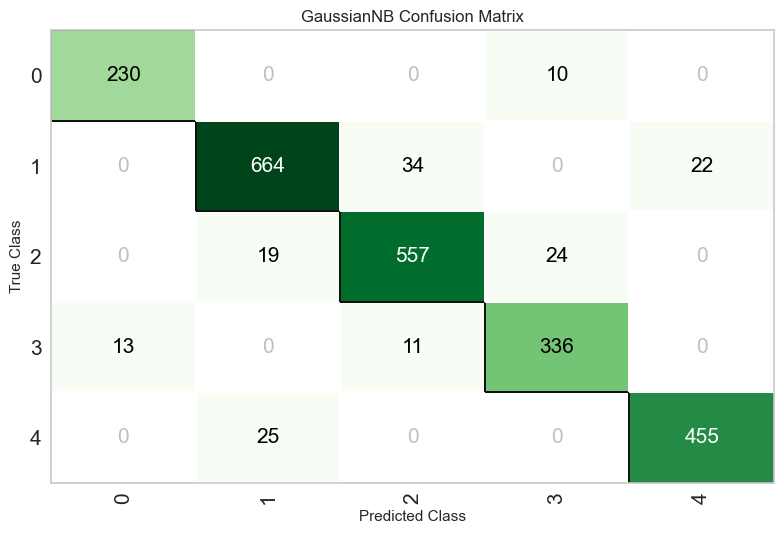

In [21]:
plot_model(model, plot='confusion_matrix')

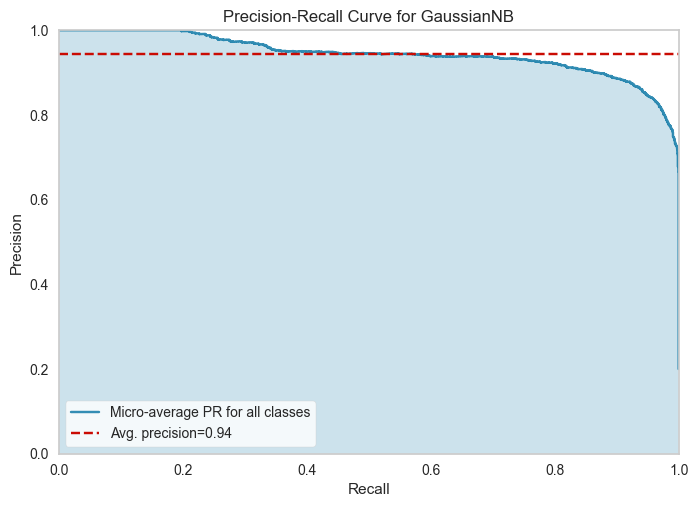

In [22]:
# Generamos la curva Precision-Recall del modelo entrenado.
plot_model(model, plot='pr')

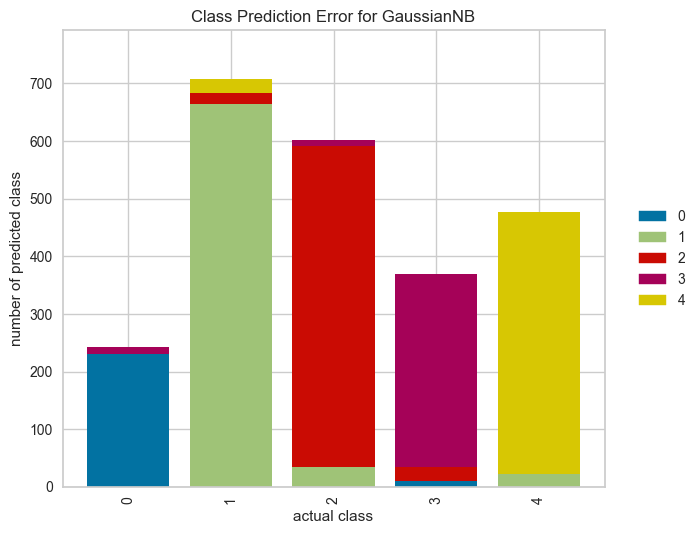

In [23]:
# Generamos el gráfico de error del modelo entrenado.
plot_model(model, plot='error')